<a href="https://colab.research.google.com/github/Chen-M-22/GridCast/blob/main/03_lstm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LSTM Forecasting
This notebook develops an LSTM for short-term ERCOT electricity demand for forecasting. Using previous 168 hours of demands, the model will predict the following 24 hours and is evaluated on the 2024 validation period against the seasonality baselines established previously.

In [1]:
import pandas as pd
import numpy as np
import keras
from keras import layers
import matplotlib.pyplot as plt

In [2]:
historical_demand_df = pd.read_csv('ercot_hourly_demand_2020_2025_clean.csv', parse_dates=['timestamp'])

In [3]:
historical_demand_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52608 entries, 0 to 52607
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  52608 non-null  datetime64[ns]
 1   demand     52608 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 822.1 KB


In [4]:
historical_demand_df.isna().sum()

,0
timestamp,0
demand,0


In [5]:
historical_demand_df['timestamp'].duplicated().sum()

np.int64(0)

In [6]:
historical_demand_df['timestamp'].diff().value_counts()

,count
timestamp,
0 days 01:00:00,52607


In [7]:
historical_demand_df.head()

,timestamp,demand
0,2020-01-01 00:00:00,40020.0
1,2020-01-01 01:00:00,41642.0
2,2020-01-01 02:00:00,40925.0
3,2020-01-01 03:00:00,39980.0
4,2020-01-01 04:00:00,39165.0


In [8]:
historical_demand_df.tail()

,timestamp,demand
52603,2025-12-31 19:00:00,49656.0
52604,2025-12-31 20:00:00,48726.0
52605,2025-12-31 21:00:00,48059.0
52606,2025-12-31 22:00:00,48037.0
52607,2025-12-31 23:00:00,48403.0


In [9]:
historical_demand_df['timestamp'].is_monotonic_increasing

True

In [10]:
# Create 168-hour input windows, 24-hour target windows,
# and chronological train, validation, and test masks.

input_length = 168
horizon = 24

x = []
y = []

target_start_times = []
target_end_times = []

for i in range (input_length, len(historical_demand_df)-horizon+1):
  x.append(historical_demand_df['demand'].iloc[i-input_length: i].values)
  y.append(historical_demand_df['demand'].iloc[i: i+horizon].values)

  target_start_times.append(historical_demand_df['timestamp'].iloc[i])
  target_end_times.append(historical_demand_df['timestamp'].iloc[i+ horizon-1])

target_start_times = pd.Series(target_start_times)
target_end_times = pd.Series(target_end_times)

train_mask = target_end_times < pd.Timestamp('2024-01-01')
validation_mask = (target_start_times >= pd.Timestamp('2024-01-01')) & (target_end_times < pd.Timestamp('2025-01-01'))
test_mask = target_start_times >= pd.Timestamp('2025-01-01')

In [11]:
print('Total Windows:', len(x))
print('Total Train:', train_mask.sum())
print('Total Validation:', validation_mask.sum())
print('Total Test:', test_mask.sum())
print('Excluded:', len(x) - train_mask.sum() - validation_mask.sum() - test_mask.sum())

Total Windows: 52417
Total Train: 34873
Total Validation: 8761
Total Test: 8737
Excluded: 46


In [12]:
x = np.array(x)
y = np.array(y)

x_train = x[train_mask]
y_train = y[train_mask]

x_val = x[validation_mask]
y_val = y[validation_mask]

x_test = x[test_mask]
y_test = y[test_mask]

In [13]:
print('Train Dataset:', x_train.shape, y_train.shape)
print('Validation Dataset:', x_val.shape, y_val.shape)
print('Test Dataset:', x_test.shape, y_test.shape)

Train Dataset: (34873, 168) (34873, 24)
Validation Dataset: (8761, 168) (8761, 24)
Test Dataset: (8737, 168) (8737, 24)


In [14]:
train_demand = historical_demand_df[historical_demand_df['timestamp'] < pd.Timestamp('2024-01-01')]['demand']

In [15]:
train_mean = train_demand.mean()
train_std = train_demand.std(ddof=0)

In [16]:
print('training data mean:', train_mean)
print('training data standard deviation:', train_std)

training data mean: 47083.72900981063
training data standard deviation: 10753.945774629803


In [17]:
# Normalization

x_train_scaled = (x_train - train_mean) / train_std
y_train_scaled = (y_train - train_mean) / train_std

x_val_scaled = (x_val - train_mean) / train_std
y_val_scaled = (y_val - train_mean) / train_std

x_test_scaled = (x_test - train_mean) / train_std
y_test_scaled = (y_test - train_mean) / train_std

In [18]:
print(x_train_scaled.shape, y_train_scaled.shape)
print(x_val_scaled.shape, y_val_scaled.shape)

print(np.isnan(x_train_scaled).sum())
print(np.isinf(x_train_scaled).sum())

(34873, 168) (34873, 24)
(8761, 168) (8761, 24)
0
0


In [19]:
# Convert input data to (samples, timesteps, features) for LSTM model.
# x has one feature, demand.

x_train_lstm = x_train_scaled[:, :, np.newaxis]
x_val_lstm = x_val_scaled[:, :, np.newaxis]
x_test_lstm = x_test_scaled[:, :, np.newaxis]

In [20]:
print(x_train_lstm.shape, y_train_scaled.shape)

(34873, 168, 1) (34873, 24)


In [21]:
x_train_lstm.min()

np.float64(-1.8258162558464772)

LSTM Model Implementation

In [ ]:
sequence_length = 168
features = 1
output_length = 24

inputs = keras.Input(shape=(sequence_length, features))
lstm_output = layers.LSTM(units=64)(inputs)
outputs = layers.Dense(units=output_length)(lstm_output)

model = keras.Model(inputs=inputs, outputs=outputs)

In [ ]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 168, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,456 (72.09 KB)

 Trainable params: 18,456 (72.09 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer ='adam',
    loss = 'mse',
    metrics = ['mae'],
)

In [ ]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor = 'val_loss',
    patience = 3,
    restore_best_weights = True
)

In [ ]:
history = model.fit(
    x = x_train_lstm,
    y = y_train_scaled,
    batch_size = 32,
    epochs = 30,
    callbacks = [early_stopping],
    validation_data=(x_val_lstm, y_val_scaled)
)

Epoch 1/30
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 75s 67ms/step - loss: 0.1313 - mae: 0.2565 - val_loss: 0.0951 - val_mae: 0.2235
Epoch 2/30
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 71s 65ms/step - loss: 0.0834 - mae: 0.2106 - val_loss: 0.0959 - val_mae: 0.2234
Epoch 3/30
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 70s 64ms/step - loss: 0.0767 - mae: 0.1995 - val_loss: 0.0870 - val_mae: 0.2123
Epoch 4/30
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 82s 64ms/step - loss: 0.0681 - mae: 0.1863 - val_loss: 0.0803 - val_mae: 0.1999
Epoch 5/30
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 71s 65ms/step - loss: 0.0637 - mae: 0.1792 - val_loss: 0.0769 - val_mae: 0.1934
Epoch 6/30
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 75s 69ms/step - loss: 0.0605 - mae: 0.1740 - val_loss: 0.0776 - val_mae: 0.1958
Epoch 7/30
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 71s 65ms/step - loss: 0.0580 - mae: 0.1707 - val_loss: 0.0767 - val_mae: 0.1976
Epoch 8/30
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 70s 64ms/step - loss: 0.0561 - mae: 0.1678 - val_loss: 0.0742 - val_mae: 0.1877
Epoch 9/30
1090/1090 ━━━

In [ ]:
history.history.keys()

dict_keys(['loss', 'mae', 'val_loss', 'val_mae'])

In [ ]:
history.history['loss']

[0.13127389550209045,
 0.0834299698472023,
 0.07665027678012848,
 0.06812261044979095,
 0.06371109187602997,
 0.060498639941215515,
 0.05803363025188446,
 0.056144773960113525,
 0.054684851318597794,
 0.053077343851327896,
 0.05383288860321045]

In [ ]:
history.history['val_loss']

[0.09505023807287216,
 0.09590944647789001,
 0.08701708167791367,
 0.08032146841287613,
 0.07694189250469208,
 0.07756978273391724,
 0.07674337923526764,
 0.07422574609518051,
 0.07465746253728867,
 0.07979482412338257,
 0.08061385899782181]

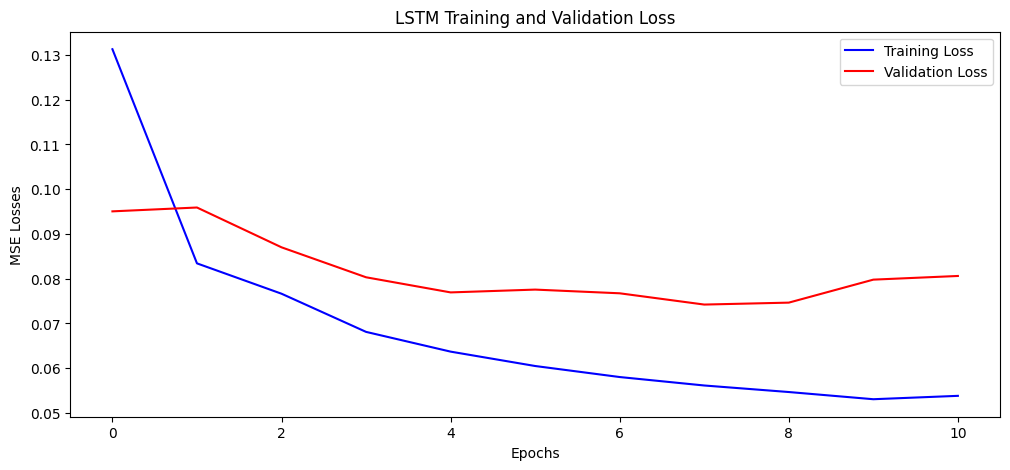

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(history.history['loss'], color='blue', label='Training Loss')
plt.plot(history.history['val_loss'], color='red', label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('MSE Losses')
plt.title('LSTM Training and Validation Loss')
plt.legend()

plt.show()

In [ ]:
sample_index = 6513

actual = y_val[sample_index]
pred_lstm_scaled = model(x_val_lstm[sample_index: sample_index+1], training=False)
pred_lstm = pred_lstm_scaled.numpy()[0] * train_std + train_mean

print('Actual Demands:', actual)
print('LSTM Prediction:', pred_lstm)

Actual Demands: [41658. 41241. 41014. 41299. 42023. 44915. 48779. 51364. 54312. 57106.
 60157. 62732. 65293. 66881. 66784. 64627. 61209. 58477. 55672. 52517.
 49454. 46474. 44463. 42590.]
LSTM Prediction: [42426.31201762 42066.96777934 42366.74316997 43418.68897075
 45050.03552837 46938.18608684 49704.94898051 52719.47754497
 55860.27783794 58721.65674419 61072.95654887 63483.31690044
 64311.99072856 64196.59424419 63931.75635356 62946.16358012
 61010.30518169 58641.00342387 55979.91358012 52730.39307231
 50070.65552348 47817.13532085 45451.88684672 43653.52710551]


In [ ]:
model.save("gridcast_lstm_v1.keras")

In [22]:
history_df = pd.DataFrame(history.history)
history_df.to_csv("lstm_training_history_v1.csv",index=False)

NameError: name 'history' is not defined

In [23]:
lstm_history_df = pd.read_csv('lstm_training_history_v1.csv')
model = keras.models.load_model('gridcast_lstm_v1.keras')

In [24]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 168, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,370 (216.29 KB)

 Trainable params: 18,456 (72.09 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 36,914 (144.20 KB)

In [25]:
y_val_pred_lstm_scaled = model(x_val_lstm, training=False)
y_val_pred_lstm = y_val_pred_lstm_scaled.numpy() * train_std + train_mean

print(y_val.shape)
print(y_val_pred_lstm.shape)

(8761, 24)
(8761, 24)


In [26]:
val_lstm_mae = np.abs(y_val - y_val_pred_lstm).mean()
val_lstm_rmse = np.sqrt(np.square(y_val - y_val_pred_lstm).mean())
normalized_val_lstm_mae = (val_lstm_mae / y_val.mean()) * 100

In [27]:
print('Validation MAE:', val_lstm_mae)
print('Validation RMSE:', val_lstm_rmse)
print('Normalized Validation MAE:', normalized_val_lstm_mae)

Validation MAE: 2018.0559166978726
Validation RMSE: 2929.8479819110694
Normalized Validation MAE: 3.8207320431416134


In [29]:
# Daily Seasonal Baseline

y_val_predict_daily = x_val[:, -24: ]

y_val_daily_mae = np.abs(y_val_predict_daily - y_val).mean()
y_val_daily_rmse = np.sqrt(np.square(y_val_predict_daily - y_val).mean())
normalized_y_val_daily_mae = (y_val_daily_mae / y_val.mean()) * 100

In [30]:
# Weekly Seasonal Baseline

y_val_predict_weekly = x_val[:, :24 ]

y_val_weekly_mae = np.abs(y_val_predict_weekly - y_val).mean()
y_val_weekly_rmse = np.sqrt(np.square(y_val_predict_weekly - y_val).mean())
normalized_y_val_weekly_mae = (y_val_weekly_mae / y_val.mean()) * 100

In [31]:
# MAE and RMSE Summary

lstm_baseline_model_results = pd.DataFrame(
    {
        'Model': ['Daily Seasonal Baseline', 'Weekly Seasonal Baseline', 'LSTM'],
        'MAE (MW)' : [y_val_daily_mae, y_val_weekly_mae, val_lstm_mae],
        'RMSE (MW)' : [y_val_daily_rmse, y_val_weekly_rmse, val_lstm_rmse],
        'Normalized MAE (%)': [normalized_y_val_daily_mae, normalized_y_val_weekly_mae, normalized_val_lstm_mae]
    }
)

lstm_baseline_model_results.round(2)

,Model,MAE (MW),RMSE (MW),Normalized MAE (%)
0,Daily Seasonal Baseline,2353.57,3402.53,4.46
1,Weekly Seasonal Baseline,4488.90,6279.17,8.50
2,LSTM,2018.06,2929.85,3.82


In [40]:
# LSTM MAE by Forecast Horizon

val_lstm_mae_by_horizon = np.abs(y_val_pred_lstm - y_val).mean(axis=0)

In [42]:
val_lstm_mae_by_horizon

array([ 577.92871229,  928.04166671, 1212.41231449, 1469.8699048 ,
       1625.43842973, 1795.61069666, 1906.53486418, 1961.58370676,
       2026.72697644, 2092.94926507, 2161.24203441, 2193.71279068,
       2245.53516862, 2278.66981457, 2296.32205435, 2299.2882023 ,
       2350.64287712, 2393.80466371, 2412.91394518, 2403.84142037,
       2437.62770902, 2455.16587562, 2434.88150947, 2472.59739821])

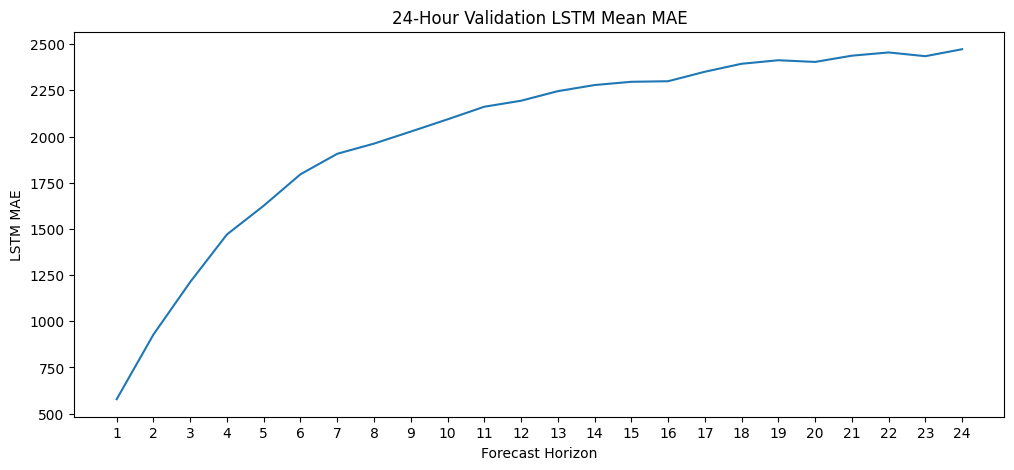

In [47]:
hours_ahead = np.arange(1, 25)

plt.figure(figsize=(12, 5))
plt.plot(hours_ahead, val_lstm_mae_by_horizon)
plt.xlabel('Forecast Horizon')
plt.ylabel('LSTM MAE')
plt.title('24-Hour Validation LSTM Mean MAE')
plt.xticks(range(1, 25))
plt.show()

In [44]:
sample_index = 6513

actual = y_val[sample_index]
pred_daily = y_val_predict_daily[sample_index]
pred_lstm = y_val_pred_lstm[sample_index].round(2)

print('Actual Demands:', actual)
print('Daily Seasonality Prediction:', pred_daily)
print('LSTM Prediction:', pred_lstm)

Actual Demands: [41658. 41241. 41014. 41299. 42023. 44915. 48779. 51364. 54312. 57106.
 60157. 62732. 65293. 66881. 66784. 64627. 61209. 58477. 55672. 52517.
 49454. 46474. 44463. 42590.]
Daily Seasonality Prediction: [42048. 41683. 42589. 44386. 45351. 47949. 50911. 52543. 54805. 57546.
 60602. 63313. 65032. 66352. 66140. 63859. 60609. 57917. 55125. 52203.
 49616. 46778. 44601. 42780.]
LSTM Prediction: [42426.31 42066.97 42366.74 43418.69 45050.04 46938.19 49704.95 52719.48
 55860.28 58721.66 61072.96 63483.32 64311.99 64196.59 63931.76 62946.16
 61010.3  58641.   55979.91 52730.4  50070.66 47817.14 45451.89 43653.53]


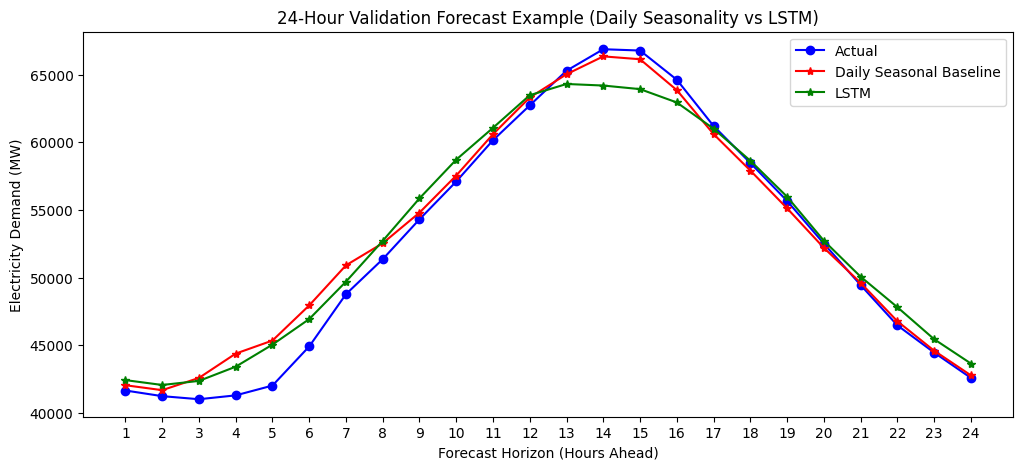

In [49]:
hours_ahead = np.arange(1, 25)

plt.figure(figsize=(12, 5))

plt.plot(hours_ahead, actual, color='blue', marker='o', label='Actual')
plt.plot(hours_ahead, pred_daily, color='red', marker='*', label='Daily Seasonal Baseline')
plt.plot(hours_ahead, pred_lstm, color='green', marker='*', label='LSTM')

plt.xlabel('Forecast Horizon (Hours Ahead)')
plt.ylabel('Electricity Demand (MW)')
plt.title('24-Hour Validation Forecast Example (Daily Seasonality vs LSTM)')
plt.xticks(range(1, 25))
plt.legend()

plt.show()

The LSTM improves overall validation performance relative to both seasonality baselines, reducing MAE by approximately 14% compared with the daily seasonal baseline. The improvement is strongest at short forecast horizons, while the daily seasonal baseline remain competitive at larger horizons and may outperform the LSTM for individual 24-hour period.